# Поиска инсайтов и точек роста

Автор:Макковеева Елена<br>
Дата: 23.09.2025

### Цель
Провести анализ данных сервиса доставки еды «Всё.из.кафе» и с его помощью ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

Провести комплексный анализ данных, а именно:
- изучить пользовательский путь и проанализировать конверсии через воронки;
- сегментировать пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризовать рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.

Такой подход позволит ближе познакомиться с работой сервиса, выявить узкие места и предложить решения для удержания пользователей и повышения эффективности сотрудничества с ресторанами.


### Данные

Данные сервиса доставки еды «Всё.из.кафе» включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка

In [1]:
#Загружаем библиотеки
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Загружаем данные в датасет df
df = pd.read_csv('https://code.s3.yandex.net/datasets/insides_data.csv', parse_dates=['first_date', 'datetime'])

In [3]:
#Выводим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

In [4]:
#Выводим первые пять строк
df.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
0,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,authorization,2021-05-01 16:07:53,NaN,NaN,NaN,NaN,NaN,NaN
1,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,reg_page,2021-05-01 16:09:16,NaN,NaN,NaN,NaN,NaN,NaN
2,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,confirm_phone,2021-05-01 16:09:19,NaN,NaN,NaN,NaN,NaN,NaN
3,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,login,2021-05-01 16:09:23,NaN,NaN,NaN,NaN,NaN,NaN
4,01b5da38-3022-48ff-87c0-5519247fef1b,567317.0,Desktop,6,Source_B,2021-05-01,171481813,main_page,2021-05-01 16:09:34,2c6095730b514c189ee41c65f03febc3,NaN,NaN,NaN,NaN,NaN


In [5]:
#Считаем количество дубликатов
print(f"Количество дубликатов: {df.duplicated().sum()}")

Количество дубликатов: 0


In [6]:
#Считаем коилчество дубликатов по user_id','datetime','event'
print(f"Количество неявных дубликатов по пользователям и совершенным действиям в момент времени:{df[['user_id','datetime','event']].duplicated().sum()}")

Количество неявных дубликатов по пользователям и совершенным действиям в момент времени:7


In [7]:
#Посмотрим на примеры дубликатов
duplicates = df[df[['user_id','datetime','event']].duplicated(keep=False)]
print("\nПримеры дубликатов:")
print(duplicates.head())


Примеры дубликатов:
                               visitor_uuid   user_id device_type  city_id  \
6053   011d6385-8508-44f6-a208-693439a959d2  570334.0     Desktop        6   
6054   011d6385-8508-44f6-a208-693439a959d2  570334.0     Desktop        6   
14373  f15a5b75-db5b-4329-a82d-31332bb4b62b  570841.0     Desktop        6   
14374  f15a5b75-db5b-4329-a82d-31332bb4b62b  570841.0     Desktop        6   
33611  34368fa2-ecc3-4285-8ba5-2cede61d9b2e  580940.0     Desktop        6   

         source first_date   visit_id          event            datetime  \
6053   Source_C 2021-05-01  172092821  authorization 2021-05-03 18:18:38   
6054   Source_C 2021-05-01  172092822  authorization 2021-05-03 18:18:38   
14373   organic 2021-05-03  172287156  authorization 2021-05-04 11:47:25   
14374   organic 2021-05-03  172287157  authorization 2021-05-04 11:47:25   
33611  Source_B 2021-05-11  174457841  authorization 2021-05-12 13:06:43   

      rest_id  object_id  order_id  revenue  delivery

In [8]:
#Удалим неявные дубликаты
df.drop_duplicates(subset=['user_id', 'datetime', 'event'], keep='first', inplace=True)

In [9]:
#Смотрим какие события проходит пользователь
df['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login', 'main_page',
       'object_page', 'add_to_cart', 'order'], dtype=object)

In [10]:
#Считаем количество уникальных пользователей
print(f'Количество уникальных пользователей {df["user_id"].nunique()}')

Количество уникальных пользователей 8473


In [11]:
#Считаем количество ресторанов-партнеров
print(f'Количество уникальных ресторанов {df["rest_id"].nunique()}')

Количество уникальных ресторанов 21


In [12]:
#Вычисляем период анализа
print(f'Период, за который представлены данные с {df["datetime"].min()} по {df["datetime"].max()}')

Период, за который представлены данные с 2021-05-01 00:10:55 по 2021-07-02 00:12:08


Загрузили данные о действиях пользователей в датасет `df`.<br> В датасете 205509 строк и 15 столбцов.<br> Неявные дубликаты в полях `user_id`, `datetime` и `event` были удалены, пропусков для обработки нет. Все столбцы имеют верный формат, преобразование не требуется.<br> В данных представлено 8473 уникальных пользоавтеля и 12 ресторанов-партнеров. Период для анализа с 1 мая 2021 года по 2 июля 2021 года.<br>Для дальйнешого анализа воронки конверсии были выведены уникальные события, которые проходит пользователь при использовании приложения `'authorization', 'reg_page', 'confirm_phone', 'login', 'main_page',
       'object_page', 'add_to_cart', 'order'`.

---

## 2. Анализ пользовательского пути

Маркетолагами было проведено исследование и было выявлено следующее: 
- деньги на рекламу тратяся по-прежнему, но заказов стало меньше
- скачивание и установка приложения остаются на том же активном уровне
- доля заказов декстопноц версии приложения увеличилось по сравнению с мобильной.

Последнее обновление мобильной версии касалось изменения нового алгоритма потверждения мобильного телефона и адреса доставки.

**Задача 2.1.** 
Построим и визуализируем классическую воронку конверсии (доля от первого шага в процентах) и Step-by-step воронку (конверсия от предыдущего шага).    

Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов (`login` не учитываем ввод логина):
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [13]:
#Задаем шаги воронки конверсии
funnel_steps = ['authorization', 'main_page','reg_page', 'confirm_phone',
       'object_page', 'add_to_cart', 'order']

In [14]:
#Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event'].isin(funnel_steps)]

In [15]:
#Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event')['visitor_uuid'].nunique().reindex(funnel_steps)

In [16]:
#Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step':funnel_steps,
   'visitors':funnel_counts.values
})

In [17]:
#Проверяем результат таблицы воронки
funnel_df

,step,visitors
0,authorization,7796
1,main_page,6835
2,reg_page,5649
3,confirm_phone,4347
4,object_page,3530
5,add_to_cart,2929
6,order,2432


In [18]:
#Считаем количество пользоавтелей на первом шаге
first_users = funnel_df.loc[funnel_df['step'] == 'authorization', 'visitors'].values[0]

In [19]:
#Считаем конверсию по шагам воронки
funnel_df['conversion_from_first_%'] = (funnel_df['visitors'] / first_users) * 100
funnel_df['conversion_from_previous_%'] = funnel_df['visitors'] / funnel_df['visitors'].shift(1) * 100

In [20]:
#Округляем полученные результаты до целого
funnel_df['conversion_from_first_%'] = funnel_df['conversion_from_first_%'].round()
funnel_df['conversion_from_previous_%'] = funnel_df['conversion_from_previous_%'].round()
#Проверяем полученные значения
funnel_df

,step,visitors,conversion_from_first_%,conversion_from_previous_%
0,authorization,7796,100.0,NaN
1,main_page,6835,88.0,88.0
2,reg_page,5649,72.0,83.0
3,confirm_phone,4347,56.0,77.0
4,object_page,3530,45.0,81.0
5,add_to_cart,2929,38.0,83.0
6,order,2432,31.0,83.0


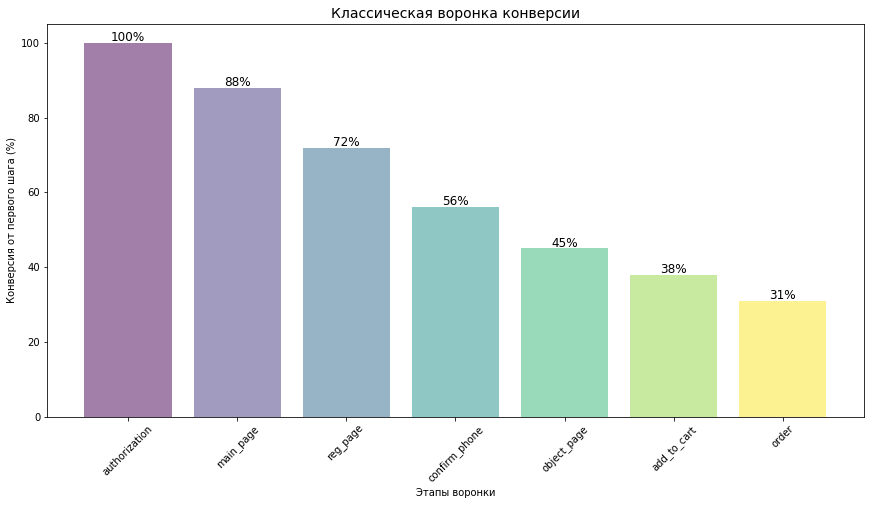

In [21]:
#Создаем фигуру для графика
plt.figure(figsize=(12, 6))
#Задаем цвета для графика
colors = plt.cm.viridis(np.linspace(0, 1, len(funnel_df)))
#Строим столбчатую диаграмму 
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color=colors, alpha=0.5)
#Подписи столбцов
for i, val in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, val + 0.5, f'{val:.0f}%', 
             ha='center', fontsize=12)

plt.tight_layout() 
plt.title('Классическая воронка конверсии', fontsize=14)
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

На основе представленной на графике классической воронки конверсии можно сделать следующие выводы:
1. **Переход на главную страницу (83%)**: пользователи успешно проходят этот этап, показатель хороший и это может говорить о том, что у пользователей не возникает проблем при загрузке главной страницы приложения.
2. **Регистрация (72%)** : до процесса регистрации доходит чуть меньше пользователей, что может говорить о низкой мотивации к регистрации. Можно добавить бонусы за регистрацию при заказе.
3. **Подтверждение номера телефона (56%)**: здесь наблюдается значительное снижение пользователей, только половина пользователей доходит до этого этапа. 
4. **Переход на страницу блюда (45%)** : конверсия продолжает снижение, что может указывать на проблемы с отображение контента.
5. **Добавление в корзину (38%)** : чуть более трети пользователей находят для себя подходящий ассортимент для добавления в корзину
6. **Заказ (31%)**: только треть пользователей доходит до заказа.<br>

Чтобы разобраться более детально, где конверсия падает сильнее всего и где приложение "теряет" пользователей, построим воронку Step-by-Step.

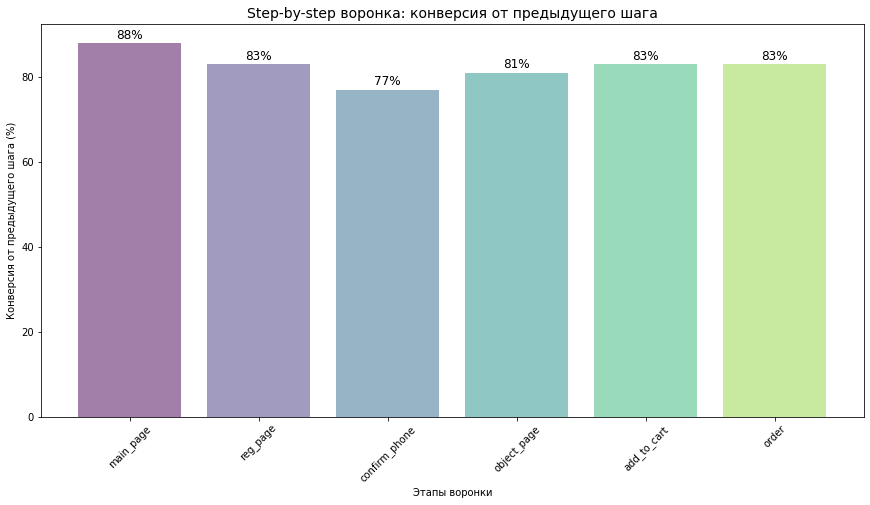

In [22]:
#Создаем фигуру для графика
plt.figure(figsize=(12, 6))
#Задаем цвета для графика
colors = plt.cm.viridis(np.linspace(0, 1, len(funnel_df)))
#Строим столбчатую диаграмму 
plt.bar(funnel_df['step'].iloc[1:], funnel_df['conversion_from_previous_%'].iloc[1:], color=colors, alpha=0.5)
#Подписи столбцов
for i, conversion in enumerate(funnel_df['conversion_from_previous_%'].iloc[1:]):
    plt.text(i, conversion + 1, f'{conversion:.0f}%', ha='center', fontsize=12)

plt.tight_layout() 
plt.title('Step-by-step воронка: конверсия от предыдущего шага', fontsize=14)
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

На графике воронки Step-by-Step видно, что больше всего пользователей уходит на этапе подтверждения номера телефона. Это может быть связано с последним обновлением мобильного приложения.<br> Чтобы окончательно подтвердить предположение, построим воронки step-by-step для декстопной и мобильной версий приложения.

**Задача 2.2.** 

Построим две воронки конверсии step-by-step для декстопной и мобильной версий приложения. Для этого разделим датасет по платформам и сохраним данные в два датасета `mobile_df` и `desktop_df`.

In [23]:
#Разделим данные по версиям приложений
mobile_df = df[df['device_type']=='Mobile']
desktop_df = df[df['device_type']=='Desktop']

In [24]:
#Фильтруем датасеты, оставляя только нужные шаги воронки
desktop_funnel = desktop_df.groupby('event')['visitor_uuid'].nunique().reindex(funnel_steps)
mobile_funnel = mobile_df.groupby('event')['visitor_uuid'].nunique().reindex(funnel_steps)

In [25]:
#Соберем через словарь данные в датафрейм для десктопной версии
desktop_df = pd.DataFrame({
    'step': funnel_steps,
    'users': desktop_funnel.values
})

In [26]:
#Соберем через словарь данные в датафрейм для мобильной версии
mobile_df = pd.DataFrame({
    'step': funnel_steps,
    'users': mobile_funnel.values
})

In [27]:
#Считаем конверсию Step-bt-Step для десктопной версии
desktop_df['CR_step,%']=((desktop_df['users'] / desktop_df['users'].shift(fill_value=desktop_df['users'].iloc[0]))*100).round()

In [28]:
#Считаем конверсию Step-bt-Step для мобильной версии
mobile_df['CR_step,%']=((mobile_df['users'] / mobile_df['users'].shift(fill_value=mobile_df['users'].iloc[0]))*100).round()

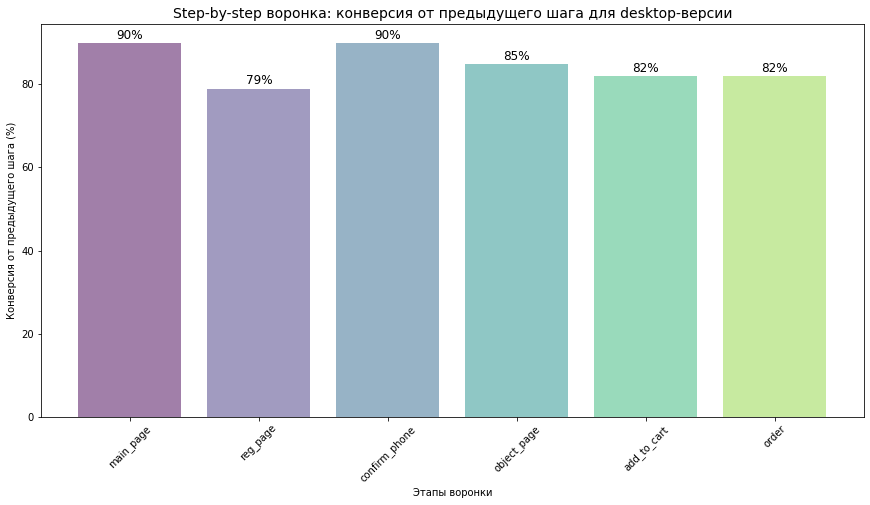

In [29]:
#Создаем фигуру для графика
plt.figure(figsize=(12, 6))
#Задаем цвета для графика
colors = plt.cm.viridis(np.linspace(0, 1, len(desktop_df)))
#Строим столбчатую диаграмму 
plt.bar(desktop_df['step'].iloc[1:], desktop_df['CR_step,%'].iloc[1:], color=colors, alpha=0.5)
#Подписи столбцов
for i, conversion in enumerate(desktop_df['CR_step,%'].iloc[1:]):
    plt.text(i, conversion + 1, f'{conversion:.0f}%', ha='center', fontsize=12)
    
plt.tight_layout()     
plt.title('Step-by-step воронка: конверсия от предыдущего шага для desktop-версии',fontsize=14)
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

В декстопной версии приложения небольшое падение конверсии наблюдается на этапе перехода на страницу регистрации. 

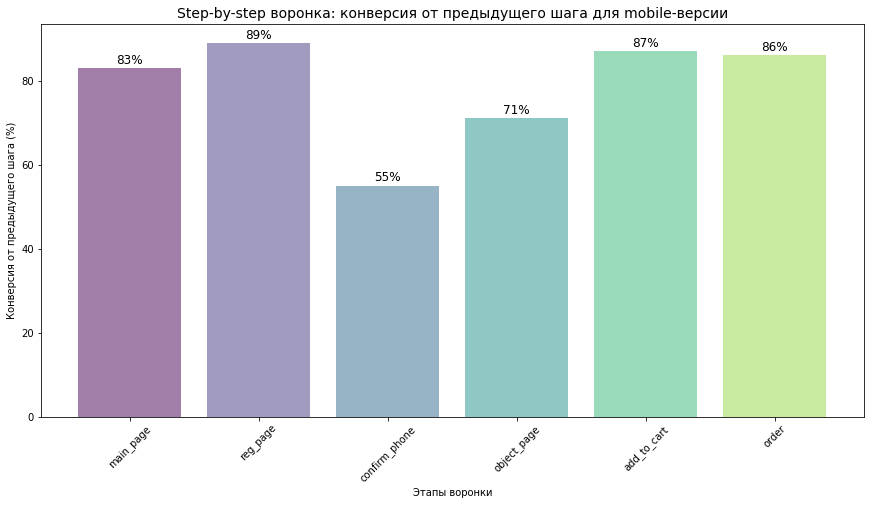

In [30]:
#Создаем фигуру для графика
plt.figure(figsize=(12, 6))
#Задаем цвета для графика
colors = plt.cm.viridis(np.linspace(0, 1, len(mobile_df)))
#Строим столбчатую диаграмму 
plt.bar(mobile_df['step'].iloc[1:], mobile_df['CR_step,%'].iloc[1:], color=colors, alpha=0.5)
#Подписи столбцов
for i, conversion in enumerate(mobile_df['CR_step,%'].iloc[1:]):
    plt.text(i, conversion + 1, f'{conversion:.0f}%', ha='center', fontsize=12)
    
plt.tight_layout()    
plt.title('Step-by-step воронка: конверсия от предыдущего шага для mobile-версии', fontsize=14)
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

В мобильной версии приложения заметно очень сильное снижение конверсии на этапе подтверждения телефона.

Пользователи мобильной версии приложения показывают более высокие результаты на некоторых шагах пользовательского пути, но сталкиваются с проблемой на этапе подтверждения телефона.<br> Пользователи декстопной версии "теряются" на этапе перехода на страницу регистрации.
Необходимо протестировать приложение на наличие ошибок и устранить их, а также собрать обратную связь от пользователей, чтобы понять каким именно аспекты процесса подтверждения телефона и перехода на страницу регистрации вызывают затруднения.

---

## 3. RFM сегментация


На основании проведенного ранее анализа удержания пользователей было выявлено, что у сервиса невысокий уровень Retention Rate. В первый день возвращается около 14% пользователей, а на 7 день только 4-5%.<br> Маркетологами предложено запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.
Для этого необходимо провести RFM сегментацию пользователей, в качестве даты анализа решено было выбрать 03 июля 2021 года.

**Задача 3.1.** 
Для каждого покупателя рассчитаем:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).

Анализ будем проводить по покупателям, у которых был хотя бы один заказ. 

In [31]:
#Отфильтруем данные по пользователям с 1 и более заказом.
data = df[df['event']=='order'].copy()

In [32]:
#Проверим минимальную выручку
data['revenue'].min()

235.2

Провели анализ минимальной выручки, она составляет 235,2, что означает, что в данных нет ошибок с отрицательным или пустым значением выручки.

In [33]:
#Выведем первые пять строк датасета
data.head()

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
91,0917eb10-d393-4d7e-a911-8721571cb499,567210.0,Mobile,6,organic,2021-05-01,171460594,order,2021-05-01 14:52:17,56edd124dfa44656afe0c0d041eba562,25349.0,590313.0,1143.156,28.1,0.04
103,0c858e35-00cb-4d8b-ad9f-d19b3b627c2f,210853.0,Desktop,6,organic,2021-05-01,171515445,order,2021-05-01 18:45:48,39b7eab4f4704ed2886fafe171489960,35102.0,590707.0,1663.200,18.2,0.11
195,0eb15742-903e-450c-9252-063cff29a094,567631.0,Desktop,6,organic,2021-05-01,171529844,order,2021-05-01 21:34:35,55d4027ac83e438f9f893892f6903409,25069.0,591008.0,3500.000,10.8,0.05
197,0eb15742-903e-450c-9252-063cff29a094,567631.0,Desktop,6,organic,2021-05-01,171529844,order,2021-05-01 21:43:34,1d6bb74687104fa1953924c9684fe624,31738.0,591028.0,610.400,38.7,0.08
199,0eb15742-903e-450c-9252-063cff29a094,567631.0,Desktop,6,organic,2021-05-01,171529844,order,2021-05-01 21:44:52,1d6bb74687104fa1953924c9684fe624,31738.0,591034.0,1220.800,15.6,0.08


In [34]:
#Рассчитываем количество дней с покупки до анализа
data['order_recency']=pd.to_datetime('2021-07-03') - data['datetime']

В качестве даты анализа выбрали 03.07.2021, поэтому рассчитываем количество дней покупки с указанной даты анализа.

In [35]:
#Группируем данные для каждого пользователя и рассчитываем данные для RFM-анализа
data_rfm = data.groupby('user_id').agg(
#Количество дней с последнего заказа:    
    recency = ('order_recency', lambda x: x.min().days),
#Количество заказов за период времени: 
    frequency = ('event', 'count'),
#Сумма стоимости всех заказов: 
    monetary= ('revenue', 'sum')
).reset_index()

In [36]:
#Выводим первые пять строк с получившимся значениями RFM
data_rfm.head()

,user_id,recency,frequency,monetary
0,5506.0,32,2,3752.00
1,6291.0,57,1,1750.00
2,6820.0,41,1,1260.14
3,11062.0,57,1,3785.60
4,13254.0,54,1,553.00


Визуализируем полученные данные по пользователям.

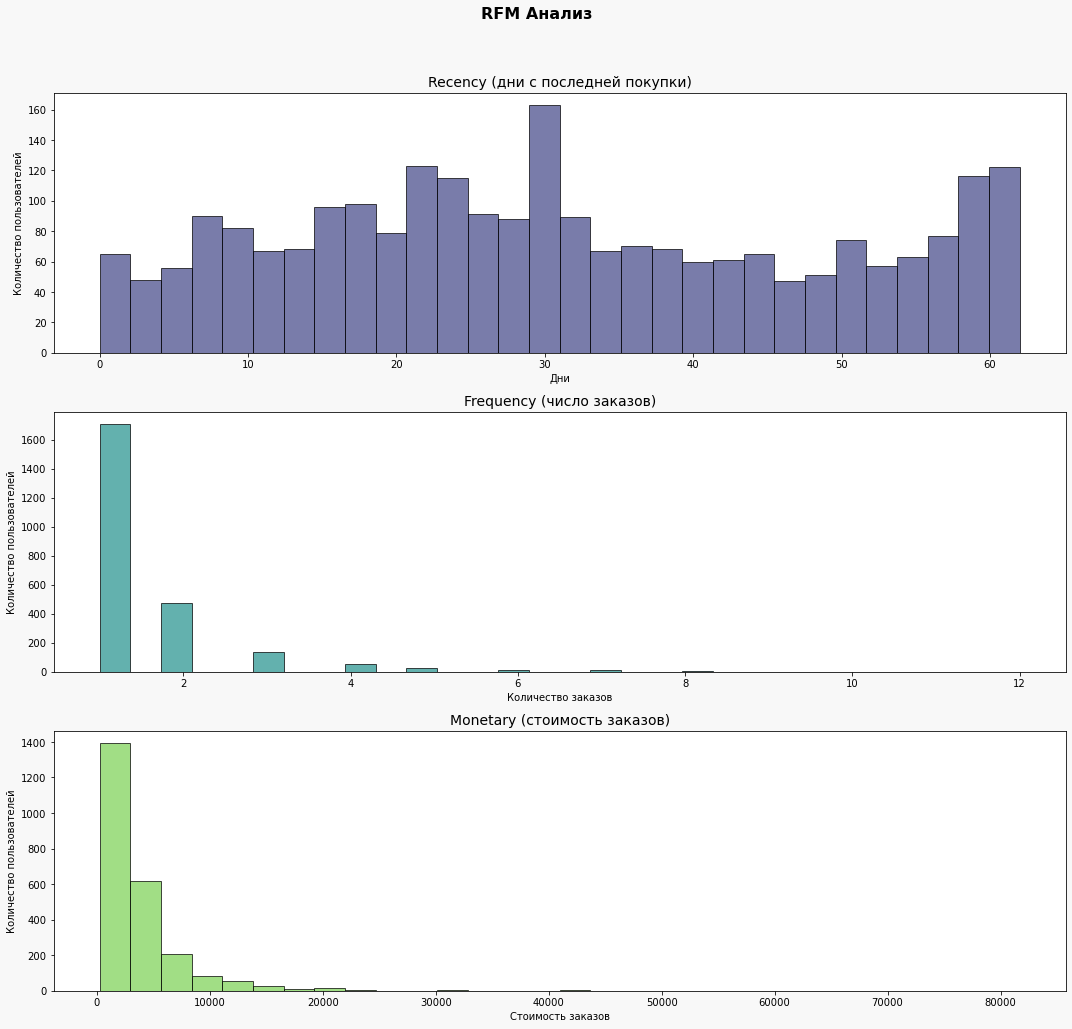

In [37]:
#Строим три гистограммы
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
plt.suptitle('RFM Анализ', fontsize=16, fontweight='bold')

#Настраиваем цветовую палитру графика
cmap = plt.get_cmap('viridis')
colors = [cmap(0.2), cmap(0.5), cmap(0.8)]

#Давность
axes[0].hist(data_rfm['recency'], bins=30, color=colors[0] , edgecolor='black', alpha=0.7)
axes[0].set_title('Recency (дни с последней покупки)', fontsize=14)
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

#Частота
axes[1].hist(data_rfm['frequency'], bins=30, color=colors[1] , edgecolor='black', alpha=0.7)
axes[1].set_title('Frequency (число заказов)', fontsize=14)
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

#Сумма всех заказов
axes[2].hist(data_rfm['monetary'], bins=30, color=colors[2] , edgecolor='black', alpha=0.7)
axes[2].set_title('Monetary (стоимость заказов)', fontsize=14)
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.patch.set_facecolor('#f8f8f8')
plt.show()

График `Recency` имеет нормальное распределение. При таком типе распределения будет правильным поделить пользователей на три равные группы, так как в каждой категории будет примерно одинаковое количество пользователей и нет ярко выраженных порогов в данных.

На графике `Frequency` видно, что большая часть пользователей совершает всего 1 заказ, поэтому здесь проведем деление на три группы:
-пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
-пользователи с 2 заказами (F-сегмент со средним количеством заказов);
-пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).

График `Monetary` имеет ассиметричное распределение с правым хвостом, присутствуют выбросы в данных. При таком распределении верно будет разделить сегменты по перцентилям (33% и 66%).

**Задача 3.2.** 

Проведем сегментацию:
- **Recency** — разделим на три равные группы.
- **Frequency** —  разделим на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделим на три группы по 33-му и 66-му перцентилям.
    
После этого посчитаем количество покупателей в каждом сегменте.

In [38]:
#Определяем группу пользователя по количеству дней с момента последнего заказа
data_rfm['r']=pd.cut(data_rfm['recency'], bins=3, labels=[3,2,1])

In [39]:
#Определяем группу пользователя по количеству заказов
data_rfm['f']=pd.cut(data_rfm['frequency'], bins=[1, 2, 3, 13], labels=[1, 2, 3], right=False)

In [40]:
#Определяем группу пользователя по сумме стоимости заказов
data_rfm['m']=pd.qcut(data_rfm['monetary'], q=3, labels=[1,2,3])

In [41]:
#Находим групповой RFM-индекс
data_rfm[['r','f','m']] = data_rfm[['r','f','m']].astype('str')
data_rfm['rfm_group'] = data_rfm['r'] + data_rfm['f'] + data_rfm['m']

In [42]:
#Выводим первые пять строк таблицы с RFM-индексом
data_rfm.head()

,user_id,recency,frequency,monetary,r,f,m,rfm_group
0,5506.0,32,2,3752.00,2,2,3,223
1,6291.0,57,1,1750.00,1,1,1,111
2,6820.0,41,1,1260.14,2,1,1,211
3,11062.0,57,1,3785.60,1,1,3,113
4,13254.0,54,1,553.00,1,1,1,111


In [43]:
#Группируем данные по сегментам и считаем их размер
rfm_group = data_rfm.groupby('rfm_group').agg({'user_id':'nunique'}).reset_index()

In [44]:
#Считаем долю пользователей в каждом сегменте
rfm_group['user_share'] = (rfm_group['user_id'] / rfm_group['user_id'].sum())*100

In [45]:
#Выводим результат
print(rfm_group.sort_values(by='user_id', ascending=False))

   rfm_group  user_id  user_share
8        211      281   11.630795
0        111      247   10.223510
17       311      246   10.182119
9        212      237    9.809603
1        112      216    8.940397
18       312      186    7.698675
10       213      122    5.049669
13       223      115    4.759934
16       233      102    4.221854
19       313       99    4.097682
22       323       88    3.642384
5        123       85    3.518212
2        113       75    3.104305
24       333       68    2.814570
12       222       59    2.442053
21       322       48    1.986755
4        122       45    1.862583
7        133       41    1.697020
3        121       16    0.662252
15       232        9    0.372517
20       321        9    0.372517
11       221        8    0.331126
6        132        8    0.331126
23       332        5    0.206954
14       231        1    0.041391


Мы получили распредление пользователей по сегментам. Можно выделить следующие группы пользователей:
1. **Основное ядро** составляют 42% от всей аудитории, именно они формируют основу выручки. Это сегменты 211, 111, 311, 212. Пользовавтели которые заказывают часто и с высоким средним чеком.
2. **Средний слой** - 34% пользователей. Это сегменты 112, 312, 213, 223, 233, 313. Заказывают нечасто и с чеком ниже среднего, не делали больше 2 заказов на момент анализа.
3. **Малоактивные** - около 8% пользователей. Это сегменты 322, 122, 133, 121, 232, 321, 221, 132, 332, 231. Это пользователи, которые сделали 2 и более заказов, но редко и с чеком ниже среднего.
4. **Отвальщики** - менее 1% пользователей. Сегменты 231, 332, 132. Давно не заказывали, тратили мало и заказывали редко. 

Для работы с этими сегментам можно дать следующие рекомендации:
1. **Основное ядро** - необходимо проработать стратегию на удержание таких пользователей, добавить персональные акции, приоритетную поддержку, бонусную программу лояльности.
2. **Средний слой** - стимулировать к повторным заказов акциями и скидками, увеличивать средний чек заказа через предоставление бесплатной доставки от определенной суммы.
3. **Малоактивные** - отправить напоминающую о сервисе рассылку, предложить промокод на первый заказ после долго перерыва.
4. **Отвальщики** - для таких пользователей не стоит выделять бюджет на маркетинг, так как они приносят минимальный вклад в выручку. Можно рассмотреть использование минимальнозатратных коммуникаций - email, push, но не смс.

---

## 4. K-Means кластеризация


По запросу от маркетологов необходимо провести кластеризацию ресторанов по следующим параметрам:
 - общее количество заказов
 - средняя стоимость заказа
 - общее число заказанных уникальных блюд.
 
С помощью метода K-Means разделим рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволит выделить группы ресторанов с похожими характеристиками и разработать для них эффективные маркетинговые стратегии.

**Задача 4.1.** Подготовим данные для кластеризации и для каждого ресторана подсчитаем:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

Чтобы рассчитать среднюю стоимость заказа, рассчитаем чистую выручку. Из суммы заказа вычтем комиссию и доставку, это и будет чистая выручка ресторанов.

In [46]:
#Расчет чистой выручки
data['rest_revenue'] = data['revenue'] * (1 - data['commission']) - data['delivery']

In [47]:
#Выводим первые три строки с результатом чистой выручет
data.head(3)

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission,order_recency,rest_revenue
91,0917eb10-d393-4d7e-a911-8721571cb499,567210.0,Mobile,6,organic,2021-05-01,171460594,order,2021-05-01 14:52:17,56edd124dfa44656afe0c0d041eba562,25349.0,590313.0,1143.156,28.1,0.04,62 days 09:07:43,1069.32976
103,0c858e35-00cb-4d8b-ad9f-d19b3b627c2f,210853.0,Desktop,6,organic,2021-05-01,171515445,order,2021-05-01 18:45:48,39b7eab4f4704ed2886fafe171489960,35102.0,590707.0,1663.200,18.2,0.11,62 days 05:14:12,1462.04800
195,0eb15742-903e-450c-9252-063cff29a094,567631.0,Desktop,6,organic,2021-05-01,171529844,order,2021-05-01 21:34:35,55d4027ac83e438f9f893892f6903409,25069.0,591008.0,3500.000,10.8,0.05,62 days 02:25:25,3314.20000


In [48]:
#Рассчитаем метрики для кластеризации
rest_metrics = data.groupby('rest_id').agg(
    total_orders = ('order_id','nunique'),  #Общее количество заказов
    avg_revenue = ('rest_revenue','mean'),  #Средняя чистая выручка
    object_counts = ('object_id','nunique')  #Уникальные блюда
).reset_index()

In [49]:
#Выводим первые три строки результата расчета метрик
rest_metrics.head(3)

,rest_id,total_orders,avg_revenue,object_counts
0,1be5a933aab34fbab594bebba48e976e,144,2055.863027,28
1,1d6bb74687104fa1953924c9684fe624,108,2697.669667,19
2,2c6095730b514c189ee41c65f03febc3,8,1549.170000,4


**Задача 4.2.** 

Нормализуем данные, убрав столбец rest_id, и найдем оптимальное количество кластеров, использовав метод `.inertia_`. Для этого построим график зависимости инерции от числа кластеров (метод "локтя") и предположим, на основании графика, оптимальное количество кластеров.

In [50]:
#Убираем столбец rest_id и оставляем только числовые данные
rest_data = rest_metrics.drop(columns=['rest_id'])
rest_data.head(3)

,total_orders,avg_revenue,object_counts
0,144,2055.863027,28
1,108,2697.669667,19
2,8,1549.170000,4


In [51]:
#Нормализуем данные
scaler = StandardScaler()
rest_data_scaled = scaler.fit_transform(rest_data)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


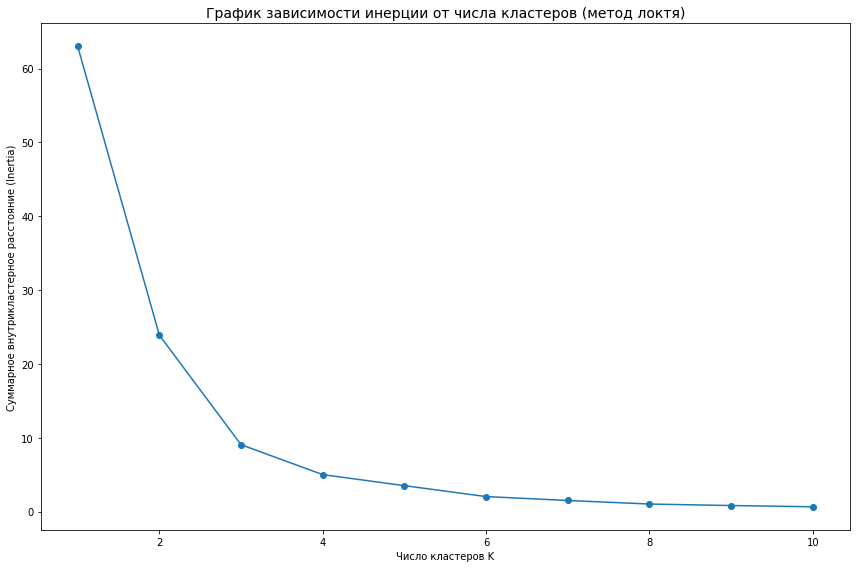

In [52]:
#Создаём массив, в котором будем хранить значения inertia для разбиения с разным числом кластеров
i = []

#Задаём диапазон количества кластеров
min_k = 1
max_k = 10

#Создаем фигуру для графика
plt.figure(figsize=(12, 8))

#Перебираем разное количество кластеров
for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)  #Создаём модель KMeans для текущего значения k
   km.fit_transform(rest_data_scaled )  #Обучаем модель и получаем координаты точек в пространстве кластеров
   i.append(km.inertia_)  #Сохраняем значение инерции для текущего k
plt.plot(range(min_k, max_k + 1), i, marker='o')

#Подписи осей и заголовок
plt.xlabel('Число кластеров K', )
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')  
plt.title('График зависимости инерции от числа кластеров (метод локтя)', fontsize=14)
plt.tight_layout()
plt.show()

Падение метрики суммарного внутрикластерного расстояния (inertia) находится в точке 3. Будем считать это оптимальным числом кластеров.

**Задача 4.3.** 

Проведем кластеризацию и проанализируем полученные результаты, рассчитав средние значения по каждому кластеру. Для кластеризации вычислили оптимальное количество кластеров равным 3.

Результаты будут визуализированы в двух зависимостях:
- средний чек в зависимости от количества заказов;
- количество блюд в зависимости от количества заказов.

In [53]:
#Создаём экземпляр модели KMeans с указанием 3 кластеров 
kmeans = KMeans(n_clusters=3, random_state=1)
#Обучаем модель на данных и сразу получаем метки кластеров для каждой строки в датафрейме
labels = kmeans.fit_predict(rest_data)

#Сортируем кластеры по возрастанию средней чистой выручки
sorted_indices = np.argsort(kmeans.cluster_centers_[:, 1])
sorted_centroids = kmeans.cluster_centers_[sorted_indices]

#Создаём датафрейм из центроидов
centroids_df = pd.DataFrame(
   sorted_centroids,
   columns=['total_orders', 'avg_revenue', 'object_counts'],
   index=[f'Кластер {i + 1}' for i in range(kmeans.n_clusters)]
)

#Форматируем числа для вывода
pd.options.display.float_format = '{:.1f}'.format

#Выводим таблицу
centroids_df.head()

,total_orders,avg_revenue,object_counts
Кластер 1,82.6,1690.4,9.8
Кластер 2,263.8,2603.5,22.8
Кластер 3,84.0,4328.0,2.5


In [54]:
#Получаем координаты центров (центроидов) кластеров
centroids = kmeans.cluster_centers_

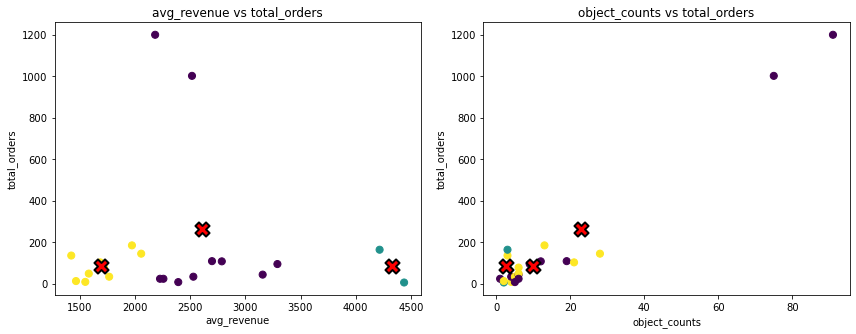

In [55]:
#Создаём 2 графика для отображения попарных комбинаций признаков
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#Список названий признаков, которые будут использоваться на графиках
axs = ["total_orders", "avg_revenue", "object_counts"]
#Перебираем пары признаков: средний чек и количество заказов, количество блюд и количество заказов
for i, (x_idx, y_idx) in enumerate([[1, 0], [2, 0]]):
   x_label, y_label = axs[x_idx], axs[y_idx]
    #Строим точки — объекты из датафрейма, раскрашенные по меткам кластера
   axes[i].scatter(
       rest_data[x_label],  #Значения по оси X
       rest_data[y_label],  #Значения по оси Y
       c=labels,  # Цветзависит от номера кластера
       cmap='viridis',  #Цветовая карта
       s=50  #Размер точек
   )

   #Строим центроиды кластеров красными крестами
   axes[i].scatter(
       centroids[:, x_idx],  #X-координаты центров
       centroids[:, y_idx],  #Y-координаты центров
       s=200,  #Размер крестов
       c='red',  #Цвет — красный
       edgecolors='black',  #Обводка — чёрная
       linewidths=2,  #Толщина обводки
       marker='X'  #Форма маркера — крест
   )

   #Подписи осей и заголовок графика
   axes[i].set_xlabel(x_label)
   axes[i].set_ylabel(y_label)
   axes[i].set_title(f'{x_label} vs {y_label}')

#Подгоняем макет, оставляя место снизу для подписи с инерцией
plt.tight_layout(rect=[0, 0.05, 1, 1])


plt.show()

С помощью графиков можем проанализировать три кластера с ресторанами:
1. **Кластер 1 (желтые точки)** - рестораны с невысоким средним чеком и низким количеством заказов, выбор блюд  чаще всего небольшой. Скорее всего это малые или начинающие рестороаны,  у которых еще нет сильного потока клиентов и ограниченное меню.
2. **Кластер 2 (фиолетовые точки)** - рестораны с большим ассортиментом блюд и средним чеком выше 2500. Кластер разнородный, сюда могут входить стабильно работающие, заработавшие популярность рестораны, либо сетевые заведения.
3. **Кластер 3 (зеленые точки)** - имеют самый высокий средний чек, но при этом ассортимент блюд ограничен, заказов также немного. Это премиальные рестораны с нишевой аудиторией.

Рекомендации по маркетинговым стратегиям, согласно кластерам, могут быть следующими:
1. **Кластер 1** - поддерживать начинающие рестораны через рекламные кампании внутри приложения, помогать расширять ассортимент, добавить акционные предложения для увеличения аудитории (скидка на первый заказ, бесплатная доставка за счет приложения).

2. **Кластер 2** - поддерживать партнерство с данными ресторанами, организовывать рекламные кампании с ресторанами как визитными карточками сервиса, проработать комбо-наборы или кросс-сервисное промо.

3. **Кластер 3** - продвигать такие рестораны как эксклюзивные, возможно выделить их в отдельный сегмент Ultima в рамках приложения с разработкой отдельного раздела с узнаваемым дизайном, проводить точечные акции для состоятельно аудитории.

---

## 5. Итоговый вывод и рекомендации


Было проведено исследование данных сервиса доставки еды из ресторанов «Всё.из.кафе». Проведена оцена конверсии пользователей от первого шага к последующим при использовании приложения, также проведено исследование воронки конверсии step-by-step по всей аудитории и по платформам использования.

Для пользователей провели RFM-сегментацию. RFM-анализ позволил оценить ценность и вовлеченность клиентов по трем параметрам:
 - Recency (R)  - давность последнего заказа
 - Frequency (F) - частота заказов
 - Monetary (M) - общий объем трат или средний чек.
 
Рестораны оценили через метод K-Means кластеризации. Кластеризация проведена по ключевым признакам:
- средний чек
- количество заказов
- количество блюд в ассортименте ресторанов.
Оптимальное расчетное количество кластеров - 3.

Кластеры проанализированы в зависимостях:
 - средний чек vs количество заказов
 - количество заказов vs ассортимент блюд

Целями задачи были обозначены три вопроса бизнеса, на которые необходимо дать ответ после проведенного анализа.

***Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?***


Согласно RFM-сегментации, около 42% пользователей составляют основное ядро приложения (часто заказывают, с высоким средним чеком), 34% - средний слой (заказы нечастые, сумма заказов ниже среднего), 8% пользователей малоактивные (сделали 2 и более заказов, но заказывают редко и с чеком ниже среднего) и менее 1% отвальщики (давно не заказывали, тратили мало и заказывали редко).

- Для основной когорты пользователей рекомендовано добавить программы лояльности и персональные предложения, проработать стратению на удержание пользователей, предоставить им приоритетную поддержку.. 
- Для среднего слоя - стимулировать повторные заказы с помощью акций, увеличивать средний чек заказа через предоставление бесплатной доставки от определенной суммы.
- Для малоактивных проработать возвратные промокоды, акции с бесплатной доставкой, отправить напоминающую о сервисе рассылку.
- Для отвальщиков - рассмотреть использование малозатратных коммуникаций (email, push) для возврата пользователей в приложение.

***Какой путь проходят пользователи в сервисе? Где «проваливаются»?***

Только 31% пользователей доходят до оформления заказа, наибольшие потери пользователей на этапе подтверждения телефона в мобильном приложении. 

Пользователи проходят 7 шагов: авторизация -> главная страница приложения -> страница регистрации -> подтверждение телефона -> страница каталога блюд -> добавление в корзину -> заказ.

В декстопной версии приложения обнаружен провал при переходе к регистрации, в мобильном - при подтверждении телефона.

Группе разработчиков и тестирования рекомендовано - протестировать и пофиксить ошибки UX в мобильном приложении. В декстопном приложении протестировать страницу регистрации и возможно добавить более удобные способы регистрации (через социальные сети, через почтовые агенты).

Для того, чтобы больше пользователей доходили до шага добавления в корзину и оформления заказа - провести оптимизацию фильтров при выборе блюд, рекомендаций при заказе.

***Как улучшить взаимодействие с партнёрами-ресторанами?***

Выделили три кластера ресторанов:
 - начинающие/малые рестораны. Имеют низкий поток заказов, низкий чек и ограниченный выбор блюд.
 - стабильные и популырные. Имеют средний чек выше 2500, широкий ассортимент, стабильный поток заказов.
 - премиальные. Имеют высокий средний чек, мало заказов и узкое меню.
 
Для малых и начинающих ресторанов рекомендовано подготовить специальное размещение, рекламные акции и помощь с расширенеием меню, проанализировов популярные блюда средних ресторанов.

Для стабильных - продвигать рестораны как визитные карточки сервиса, проводить кросс-промо, добавить комбо-наборы.

Для премиальных - выделить в отдельный сегмент с узнаваемым названием, проводить совместные акции с известными шеф-поварами или ресторанами с мишленовскими звездами, продвигать имиджевое партнерство, то есть работа на бренд и доверие, а не на моментальные продажи.